In [ ]:
import numpy as np
import gstools as gs
import matplotlib.pyplot as plt
from scipy.ndimage import convolve
from pgs_tools import make_gaussian_fields, make_lithotype_map, plot_fields, plot_lithotype_map
from ca_tools import get_neighbours, decide_new_state, run_ca, plot_ca_evolution, summarize_stability




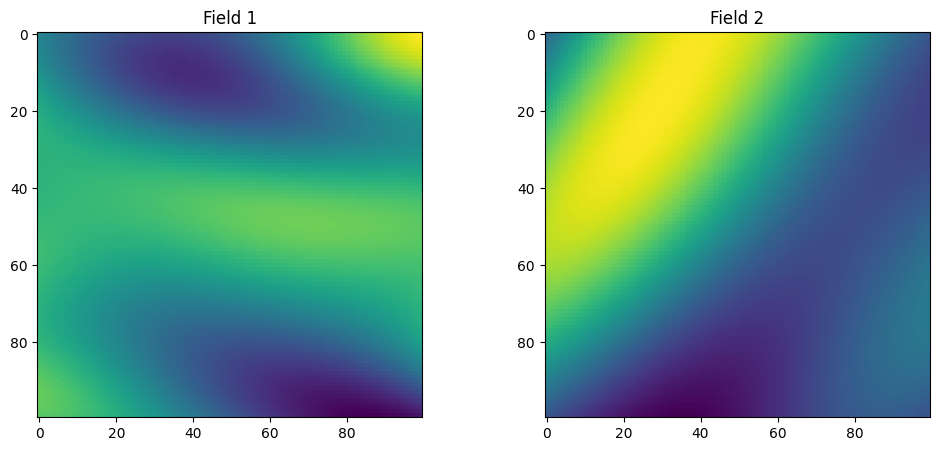

In [2]:
field_1_2d, field_2_2d = make_gaussian_fields(
    grid_size=100,
    len_scale_1=[25, 50], angles_1=[0, 0], seed_1=1,
    len_scale_2=[50, 100], angles_2=[np.pi/4, np.pi/4], seed_2=2
)


plot_fields(field_1_2d, field_2_2d, cmap='viridis', figsize=(12, 5))


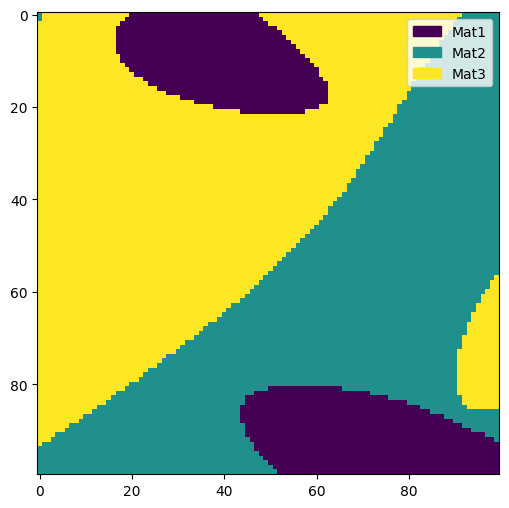

In [3]:
from pgs_tools import make_lithotype_map, plot_lithotype_map

lithotype_map = make_lithotype_map(field_1_2d, field_2_2d, Mat1=0.20, Mat2=0.50, Mat3=0.30)

plot_lithotype_map(lithotype_map, cmap='viridis')

In [4]:

lithotype_map, snapshots = run_ca(lithotype_map,
       generations=10,
       threshold=1,
       checkpoints = list(range(1, 11))
)
      

Generation 1:
  Rock type 0: 16.5%
  Rock type 1: 39.3%
  Rock type 2: 44.2%
Generation 2:
  Rock type 0: 17.0%
  Rock type 1: 40.0%
  Rock type 2: 43.0%
Generation 3:
  Rock type 0: 17.5%
  Rock type 1: 40.7%
  Rock type 2: 41.8%
Generation 4:
  Rock type 0: 17.8%
  Rock type 1: 41.5%
  Rock type 2: 40.6%
Generation 5:
  Rock type 0: 18.2%
  Rock type 1: 42.3%
  Rock type 2: 39.5%
Generation 6:
  Rock type 0: 18.5%
  Rock type 1: 43.1%
  Rock type 2: 38.4%
Generation 7:
  Rock type 0: 18.8%
  Rock type 1: 43.9%
  Rock type 2: 37.3%
Generation 8:
  Rock type 0: 19.0%
  Rock type 1: 44.7%
  Rock type 2: 36.3%
Generation 9:
  Rock type 0: 19.2%
  Rock type 1: 45.5%
  Rock type 2: 35.2%
Generation 10:
  Rock type 0: 19.4%
  Rock type 1: 46.3%
  Rock type 2: 34.3%


ValueError: too many values to unpack (expected 2)

In [5]:
plot_ca_evolution(snapshots, interval=500, cmap='viridis', figsize=(12, 5))

NameError: name 'snapshots' is not defined

In [6]:
from ca_tools import get_neighbours

test_grid = np.array([
    [0, 1, 2],
    [1, 1, 0],
    [2, 0, 1]
])



print(get_neighbours(test_grid, 1, 1))                          # should be unchanged: [1, 0, 1, 0]
print(get_neighbours(test_grid, 1, 1, neighbourhood='moore'))   # should add the 4 diagonals

([np.int64(1), np.int64(1), np.int64(0), np.int64(0)], [1, 1, 1, 1])
([np.int64(0), np.int64(1), np.int64(2), np.int64(1), np.int64(0), np.int64(2), np.int64(0), np.int64(1)], [1, 1, 1, 1, 1, 1, 1, 1])


In [7]:
print(sorted(get_neighbours(test_grid, 1, 1)))                         # expect [0, 0, 1, 1]
print(sorted(get_neighbours(test_grid, 1, 1, neighbourhood='moore')))  # expect [0, 0, 0, 1, 1, 1, 2, 2]


big_grid = np.arange(25).reshape(5, 5) % 3
print(len(get_neighbours(big_grid, 2, 2, neighbourhood='von_neumann', radius=2)))  # expect 12
print(len(get_neighbours(big_grid, 2, 2, neighbourhood='moore', radius=2)))        # expect 24

[[np.int64(1), np.int64(1), np.int64(0), np.int64(0)], [1, 1, 1, 1]]
[[np.int64(0), np.int64(1), np.int64(2), np.int64(1), np.int64(0), np.int64(2), np.int64(0), np.int64(1)], [1, 1, 1, 1, 1, 1, 1, 1]]
2
2


In [8]:
print(sorted(get_neighbours(test_grid, 1, 1)))                         # expect [0, 0, 1, 1]
print(len(get_neighbours(big_grid, 2, 2, neighbourhood='von_neumann', radius=2)))  # expect 12

print(sorted(get_neighbours(test_grid, 0, 0, boundary='periodic')))  # expect [1, 1, 2, 2]

[[np.int64(1), np.int64(1), np.int64(0), np.int64(0)], [1, 1, 1, 1]]
2
[[1, 1, 1, 1], [np.int64(2), np.int64(2), np.int64(1), np.int64(1)]]


In [9]:
print(sorted(get_neighbours(test_grid, 1, 1)))  # expect [0, 0, 1, 1]

print(sorted(get_neighbours(test_grid, 1, 0, boundary='reflective')))  # expect [0, 1, 1, 2]

[[np.int64(1), np.int64(1), np.int64(0), np.int64(0)], [1, 1, 1, 1]]
[[np.int64(0), np.int64(1), np.int64(1), np.int64(2)], [1, 1, 1, 1]]


In [10]:
values, weights_out = get_neighbours(test_grid, 1, 1)
print(sorted(values))  # expect [0, 0, 1, 1] - regression check, unweighted defaults

values, weights_out = get_neighbours(test_grid, 1, 1, neighbourhood='moore', direct_weight=2, diagonal_weight=1)
print(list(zip(values, weights_out)))  # direct neighbours should show weight 2, diagonals weight 1

[np.int64(0), np.int64(0), np.int64(1), np.int64(1)]
[(np.int64(0), 1), (np.int64(1), 2), (np.int64(2), 1), (np.int64(1), 2), (np.int64(0), 2), (np.int64(2), 1), (np.int64(0), 2), (np.int64(1), 1)]


In [11]:
print(decide_new_state([1, 1, 1, 0], current_state=0, threshold=1))  # expect 1 (majority of 3 beats threshold)
print(decide_new_state([1, 1, 0, 0], current_state=0, threshold=2))  # expect 0 (tied 2-2, doesn't clear threshold, stays put)

1
0


In [12]:
print(decide_new_state([1, 1, 1, 0], current_state=0, threshold=1))  # expect 1
print(decide_new_state([1, 1, 0, 0], current_state=0, threshold=2))  # expect 0

print(decide_new_state([1, 1, 0, 0], current_state=0, threshold=3, neighbour_weights=[2, 2, 1, 1]))
# unweighted this tied 2-2; weighted, state 1 gets 2+2=4 and state 0 gets 1+1=2, so 4 > threshold(3) -> expect 1

1
0
1


In [13]:
print(decide_new_state([1, 1, 1, 0], current_state=0, threshold=1))  # expect 1

print(decide_new_state([0, 0, 0, 1], current_state=1, threshold={0: 1, 1: 3, 2: 1}))  # expect 1 (protected, stays)
print(decide_new_state([0, 0, 0, 1], current_state=2, threshold={0: 1, 1: 3, 2: 1}))  # expect 0 (flips easily)

1
1
0


In [14]:
print(decide_new_state([1, 1, 1, 0], current_state=0, threshold=1))  # expect 1


matrix = np.array([[0, 0, 5], [0, 0, 10], [5, 10, 0]])

print(decide_new_state([1, 1, 1, 2], current_state=0, rule='probabilistic',
                        interaction_matrix=matrix, temperature=0))
# switching is energetically unfavourable here, and temperature=0 forbids unfavourable
# switches entirely - expect 0 (stays put, ignoring the majority)

rng = np.random.default_rng(0)
switches = sum(
    decide_new_state([1, 1, 1, 2], current_state=0, rule='probabilistic',
                      interaction_matrix=matrix, temperature=10, rng=rng) == 1
    for _ in range(1000)
)
print(switches / 1000)  # expect roughly 0.6

1
0
0.585


In [15]:
rng = np.random.default_rng(0)
test_map = rng.integers(0, 3, size=(10, 10))
result_map, snaps = run_ca(test_map.copy(), generations=5, checkpoints=[5], threshold=1)

Generation 5:
  Rock type 0: 49.0%
  Rock type 1: 31.0%
  Rock type 2: 20.0%


ValueError: too many values to unpack (expected 2)

In [16]:
rng = np.random.default_rng(0)
test_map = rng.integers(0, 3, size=(10, 10))
result_map, snaps = run_ca(test_map.copy(), generations=5, checkpoints=[5], threshold=1)

Generation 5:
  Rock type 0: 49.0%
  Rock type 1: 31.0%
  Rock type 2: 20.0%


ValueError: too many values to unpack (expected 2)

In [17]:
# 1. defaults - should run without error, percentages may differ slightly from before (edges now active)
run_ca(test_map.copy(), generations=5, checkpoints=[5], threshold=1)

# 2. periodic boundary - edge cells get full neighbour counts now, should behave differently than fixed
run_ca(test_map.copy(), generations=5, checkpoints=[5], threshold=1, boundary='periodic')

# 3. probabilistic rule - just confirming it runs end-to-end without crashing
run_ca(test_map.copy(), generations=5, checkpoints=[5], rule='probabilistic', temperature=5)

Generation 5:
  Rock type 0: 49.0%
  Rock type 1: 31.0%
  Rock type 2: 20.0%
Generation 5:
  Rock type 0: 62.0%
  Rock type 1: 28.0%
  Rock type 2: 10.0%
Generation 5:
  Rock type 0: 57.0%
  Rock type 1: 28.0%
  Rock type 2: 15.0%


(array([[0, 2, 0, 1, 0, 1, 0, 1, 0, 0],
        [2, 0, 1, 0, 1, 0, 1, 0, 2, 0],
        [0, 0, 0, 0, 0, 1, 0, 1, 0, 2],
        [0, 0, 0, 0, 1, 0, 1, 0, 0, 0],
        [0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
        [2, 1, 2, 0, 1, 0, 1, 0, 2, 1],
        [1, 2, 1, 2, 0, 1, 0, 2, 1, 2],
        [0, 1, 0, 0, 0, 0, 1, 1, 2, 1],
        [0, 0, 0, 0, 0, 1, 0, 2, 1, 2],
        [0, 0, 0, 0, 0, 0, 1, 1, 2, 1]]),
 {5: array([[0, 2, 0, 1, 0, 1, 0, 1, 0, 0],
         [2, 0, 1, 0, 1, 0, 1, 0, 2, 0],
         [0, 0, 0, 0, 0, 1, 0, 1, 0, 2],
         [0, 0, 0, 0, 1, 0, 1, 0, 0, 0],
         [0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
         [2, 1, 2, 0, 1, 0, 1, 0, 2, 1],
         [1, 2, 1, 2, 0, 1, 0, 2, 1, 2],
         [0, 1, 0, 0, 0, 0, 1, 1, 2, 1],
         [0, 0, 0, 0, 0, 1, 0, 2, 1, 2],
         [0, 0, 0, 0, 0, 0, 1, 1, 2, 1]])},
 [array([0.36, 0.37, 0.27]),
  array([0.44, 0.35, 0.21]),
  array([0.49, 0.33, 0.18]),
  array([0.53, 0.31, 0.16]),
  array([0.57, 0.28, 0.15])])

In [18]:
result, snaps = run_ca(test_map.copy(), generations=5, checkpoints=[5], threshold=1)
result, snaps = run_ca(test_map.copy(), generations=5, checkpoints=[5], threshold=1, update_scheme='asynchronous')

Generation 5:
  Rock type 0: 49.0%
  Rock type 1: 31.0%
  Rock type 2: 20.0%


ValueError: too many values to unpack (expected 2)

In [19]:
locked = np.zeros((10, 10), dtype=bool)
locked[0:3, 0:3] = True

before = test_map.copy()
result, snaps = run_ca(test_map.copy(), generations=5, checkpoints=[5], threshold=1, locked_mask=locked)

print(np.array_equal(result[0:3, 0:3], before[0:3, 0:3]))  # expect True - locked region untouched
print(np.array_equal(result, before))                       # expect False - rest of grid changed

Generation 5:
  Rock type 0: 43.0%
  Rock type 1: 35.0%
  Rock type 2: 22.0%


ValueError: too many values to unpack (expected 2)

In [20]:
uniform_grid = np.zeros((10, 10), dtype=int)

# no nucleation - nothing should change at all
result0, snaps0 = run_ca(uniform_grid.copy(), generations=5, checkpoints=[5], threshold=100)
print((result0 != 0).sum())  # expect 0

# nucleation on - some cells should now be non-zero, purely from spontaneous flips
result1, snaps1 = run_ca(uniform_grid.copy(), generations=1, checkpoints=[1], threshold=100, nucleation_rate=0.3)
print((result1 != 0).sum())  # expect roughly 30 (about 30% of 100 cells)

Generation 5:
  Rock type 0: 100.0%
  Rock type 1: 0.0%
  Rock type 2: 0.0%


ValueError: too many values to unpack (expected 2)

In [21]:
rng = np.random.default_rng(0)
imbalanced = rng.choice([0, 1, 2], size=(30, 30), p=[0.2, 0.5, 0.3])

# baseline - no conservation, drift expected
result_a, snaps_a = run_ca(imbalanced.copy(), generations=20, checkpoints=[20], threshold=1)

# with conservation feedback targeting the original proportions
target = {0: 0.2, 1: 0.5, 2: 0.3}
result_b, snaps_b = run_ca(imbalanced.copy(), generations=20, checkpoints=[20], threshold=1,
                            target_proportions=target, conservation_strength=0.3)

Generation 20:
  Rock type 0: 34.8%
  Rock type 1: 63.7%
  Rock type 2: 1.6%


ValueError: too many values to unpack (expected 2)

In [23]:
result, snaps, history = run_ca(test_map.copy(), generations=15, checkpoints=[15], threshold=1)
summarize_stability(history, window=5, tolerance=1.0)

Generation 15:
  Rock type 0: 61.0%
  Rock type 1: 19.0%
  Rock type 2: 20.0%


NameError: name 'summarize_stability' is not defined